# 3.1 Возвращаемся к деревьям

In [3]:
import zipfile

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [4]:
with zipfile.ZipFile('titanic.zip') as z:
    with z.open('train.csv') as f: # specify exact path inside ZIP
        df = pd.read_csv(f)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Отбираем X (независимые переменные)

In [6]:
X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)

In [7]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [8]:
X = pd.get_dummies(X, dtype=int)
X

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,0,1,0,0,1
887,1,19.0,0,0,30.0000,1,0,0,0,1
888,3,NaN,1,2,23.4500,1,0,0,0,1
889,1,26.0,0,0,30.0000,0,1,1,0,0


In [9]:
X['Age'].median()

28.0

In [10]:
X['Age'] = X['Age'].fillna(X['Age'].median())

### Отбираем зависимую переменную y

In [12]:
y = df['Survived']

### Делим данные на train и test

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Создаем объект модели - дерево решений

- min_sample_split - параметр, устанавливающий допустимый размер выборки для дальнейшего сплита. Т.е. если после сплита остается более 100 наблюдений, будет следующий сплит, если меньше - то нет.
- min_samples_leaf - Минимальное количество выборок, необходимое для того, чтобы они находились в конечном узле (самые нижние прямоугольнички).
- min_impurity_decrease - Узел будет разделен, если это разделение приведет к уменьшению примеси, превышающему или равному этому значению. Ожидаемое минимальное уменьшение неопределенности (IG)

In [17]:
clf = sklearn.tree.DecisionTreeClassifier(criterion='entropy', max_depth = 3, min_samples_split=100, min_samples_leaf=10)

In [18]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=10,
                       min_samples_split=100)

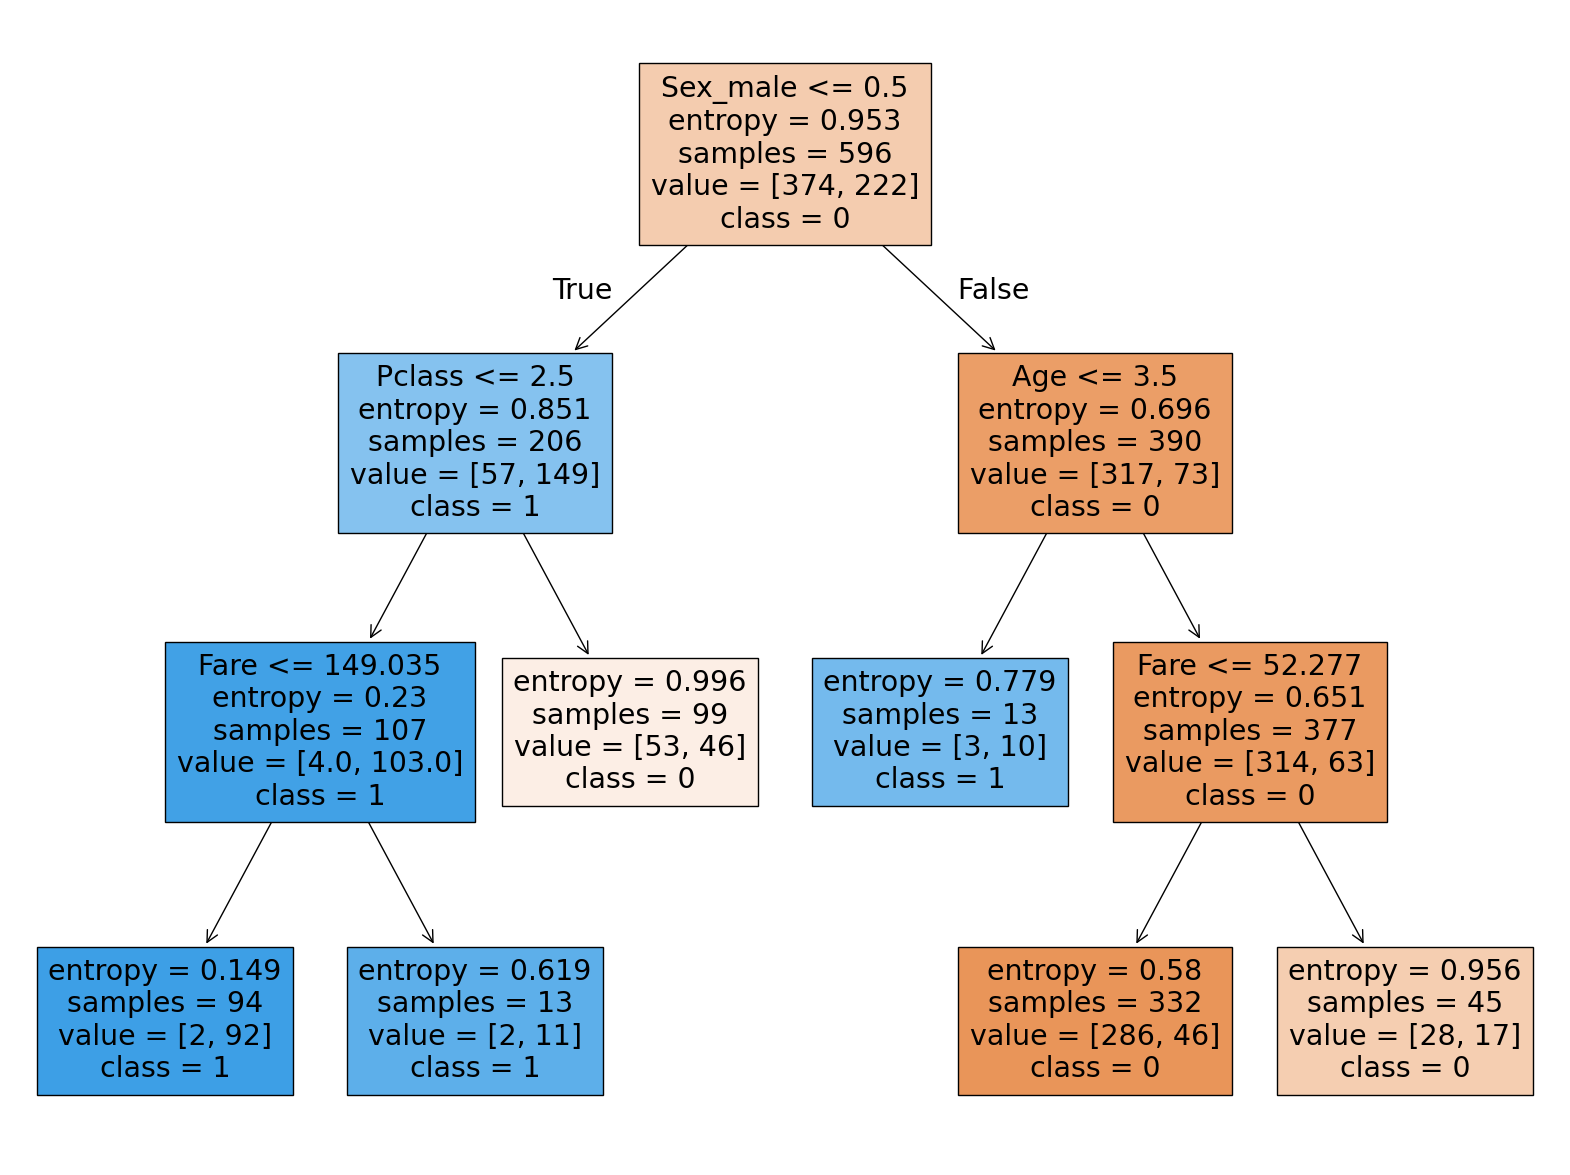

In [19]:
plt.figure(figsize=(20,15))
sklearn.tree.plot_tree(clf, feature_names=list(X),
                       class_names=['0', '1'],
                       filled=True);

# 3.2 Random Forest

DeepSeek

Random Forest — это алгоритм машинного обучения, основанный на ансамбле решающих деревьев. Он используется для задач классификации и регрессии.

Основная идея: объединение множества «слабых» моделей (деревьев) для получения одной сильной и устойчивой модели, что позволяет снизить переобучение.

Краткий алгоритм построения:
- Бутстреп (Bootstrap): Из исходного тренировочного набора данных случайным образом создается несколько новых наборов того же размера (выборки с повторениями). Т.е. размер выборки равен размеру тренировочного датасета, т.к. строки повторяются. Для каждого дерева берется свой набор.

- Случайный подбор признаков: При построении каждого отдельного дерева на каждом разбиении (узле) рассматривается не все признаки, а только случайное подмножество признаков (обычно размером sqrt(n) для классификации или n/3 для регрессии).

- Построение деревьев: Каждое решающее дерево строится независимо на своем бутстреп-наборе данных до максимальной глубины (без существенной обрезки ветвей).

- Агрегация (Голосование):

  - Для классификации: Финальный класс определяется голосованием деревьев (какое дерево какой класс предсказало).

  - Для регрессии: Финальное значение вычисляется как среднее арифметическое предсказаний всех деревьев.

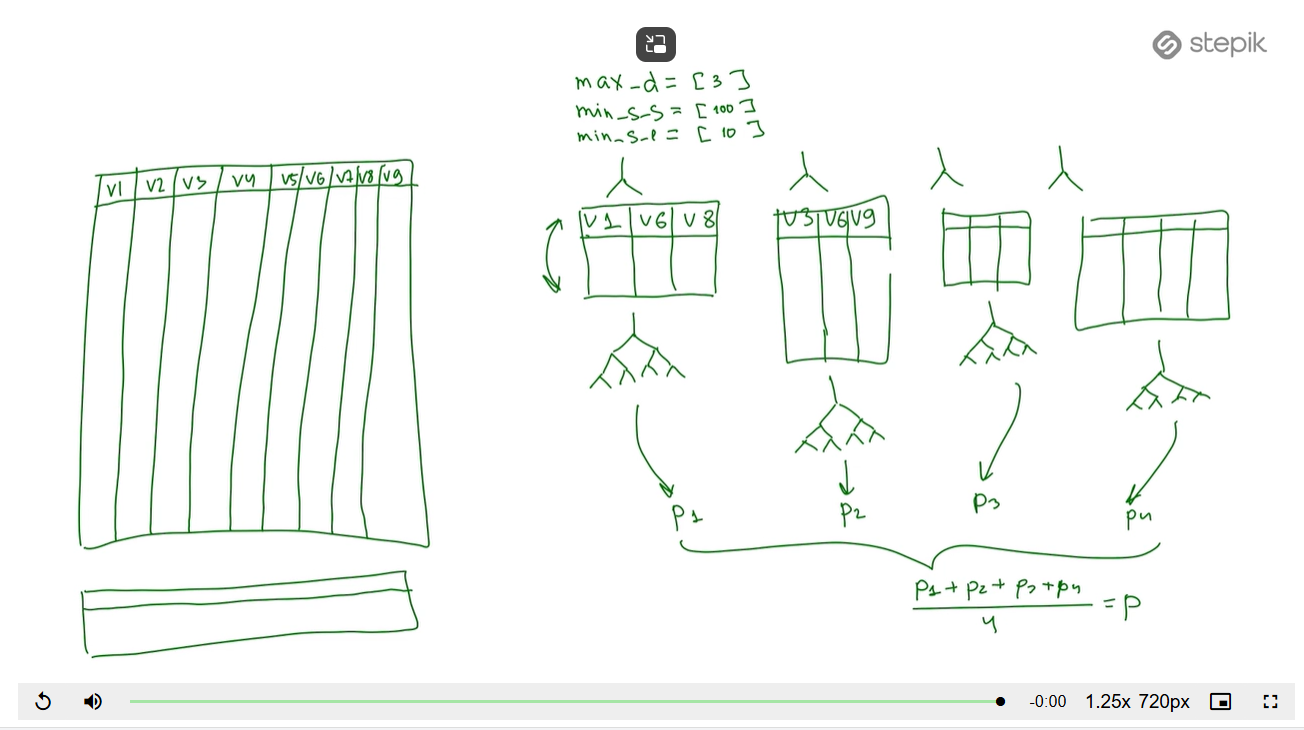

## Комментарий

Допустим, мы хотим построить 10 деревьев. Эти деревья будут построены совершенно независимо друг от друга, и алгоритм будет случайным образом отбирать признаки для построения каждого дерева, чтобы получить непохожие друг на друга деревья.


Для построения дерева мы сначала сформируем бутстреп-выборку (bootstrap sample) наших данных. То есть из n_samples примеров мы случайным образом выбираем пример с возвращением n_samples раз (поскольку отбор с возвращением, то один и тот же пример может быть выбран несколько раз). Мы получаем выборку, которая имеет такой же размер, что и исходный набор данных, однако некоторые примеры будут отсутствовать в нем (примерно одна треть), а некоторые попадут в него несколько раз.


Чтобы проиллюстрировать это, предположим, что мы хотим создать бутстреп-выборку списка ['a', 'b', 'c', 'd']. Возможная бутстреп- выборка может выглядеть как ['b', 'd', 'd', 'c']. Другой возможной бутстреп-выборкой может быть ['d', 'a', 'd', 'a']. Далее на основе этой сформированной бутстреп-выборки строится дерево решений. Вместо поиска наилучшего теста для каждого узла, алгоритм для разбиения узла случайным образом отбирает подмножество признаков и затем находит наилучший тест, используя один из этих признаков. Количество отбираемых признаков контролируется параметром max_features. Отбор подмножества признаков повторяется отдельно для каждого узла, поэтому в каждом узле дерева может быть принято решение с использованием «своего» подмножества признаков.


Использование бутстрепа приводит к тому, что деревья решений в случайном лесе строятся на немного отличающихся между собой бутстреп-выборках.


Из-за случайного отбора признаков в каждом узле все расщепления в деревьях будут основано на отличающихся подмножествах признаков. Вместе эти два механизма приводят к тому, что все деревья в случайном лесе отличаются друг от друга.

## RandomForestClassifier

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
clf_rf = RandomForestClassifier()

In [28]:
parameters = {'n_estimators': [10, 20, 30], 'max_depth': [2, 5, 7, 10]}

In [29]:
grid_search_cv_clf = GridSearchCV(estimator=clf_rf, param_grid=parameters, cv=5)

In [30]:
grid_search_cv_clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 5, 7, 10],
                         'n_estimators': [10, 20, 30]})

In [31]:
grid_search_cv_clf.best_estimator_

RandomForestClassifier(max_depth=7, n_estimators=30)

In [32]:
grid_search_cv_clf.best_params_

{'max_depth': 7, 'n_estimators': 30}

## features_name и feature_importances_df

In [34]:
best_clf = grid_search_cv_clf.best_estimator_

In [35]:
best_clf.score(X_test, y_test)

0.8

In [36]:
features_name = best_clf.feature_names_in_

In [37]:
feature_importances = best_clf.feature_importances_

In [38]:
feature_importances_df = pd.DataFrame({'features': features_name,
                                       'feature_importances': feature_importances}
                                     )

In [39]:
feature_importances_df.sort_values(by='feature_importances', ascending=False)

,features,feature_importances
6,Sex_male,0.262369
4,Fare,0.188078
1,Age,0.157887
5,Sex_female,0.146510
0,Pclass,0.111414
2,SibSp,0.040886
3,Parch,0.035030
7,Embarked_C,0.026150
9,Embarked_S,0.018704
8,Embarked_Q,0.012972


<Axes: title={'center': 'feature importances'}, xlabel='features_name', ylabel='features_importances'>

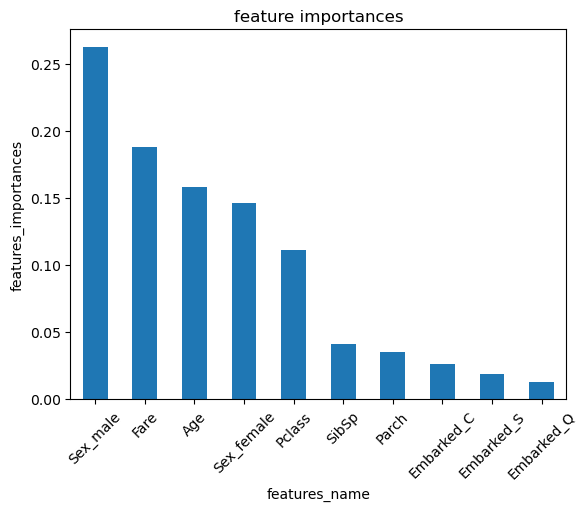

In [40]:
(feature_importances_df.
 set_index('features').
 sort_values(by='feature_importances', ascending=False).
 plot(kind='bar', rot=45, legend=False, title='feature importances', xlabel = 'features_name', ylabel = 'features_importances')
)

Предсказания, которые дают модели, это уже хорошо, однако не всегда достаточно. С разными усилиями, мы также можем извлечь важность переменных для осуществления предсказания. Это особенно интересно в науке, где мы пытаемся выявить причинно-следственные связи (хотя, от важности переменных до проверки этих связей ещё длинный путь). Из Decision Tree и Random Forest легко вытащить важность переменных для предсказания, но есть одна особенность. При высокой скореллированности нескольких переменных сплит по любой из них может давать одинаковый Information Gain, и выбор будет сделан случайно. То есть, важность фичей может изменяться в зависимости от выбора из равноценных в процессе обучения. Поэтому следует смотреть на корреляцию между переменными перед обучением, чтобы лучше представлять данные.

## Практическое задание

In [43]:
heart_desease = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/heart-disease.csv')

In [44]:
heart_desease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [45]:
X = heart_desease.drop('target', axis=1)

In [46]:
y = heart_desease['target']

In [47]:
rf = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=0)

In [48]:
rf.fit(X, y)

RandomForestClassifier(max_depth=5, n_estimators=10, random_state=0)

In [49]:
feature_importances_df = pd.DataFrame({'features': rf.feature_names_in_,
                                       'feature_importances': rf.feature_importances_}
                                     )

<Axes: title={'center': 'feature importances'}, xlabel='features_importances', ylabel='features_name'>

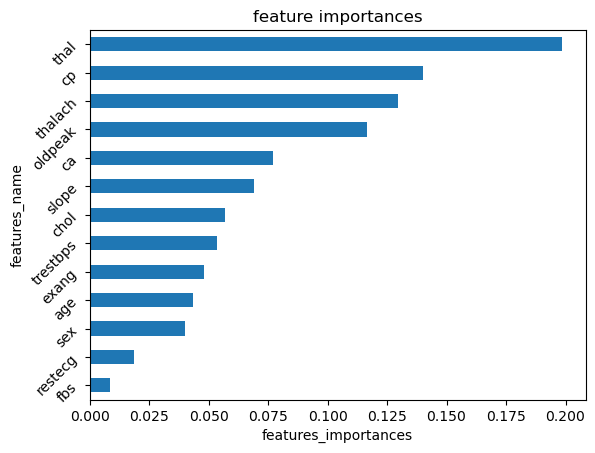

In [50]:
(feature_importances_df.
 set_index('features').
 sort_values(by='feature_importances', ascending=True).
 plot(kind='barh', rot=45, legend=False, title='feature importances', xlabel = 'features_importances', ylabel = 'features_name')
)

# 3.3 Зачем знать что-то еще, если есть Random Forest?

В 1906 г. в городе Плимут (Великобритания) на сельской ярмарке был проведен эксперимент. Френсис Гальтон в качестве развлечения посетителей ярмарки предложил на глаз оценить вес выставленного на всеобщее обозрение быка и написать эту цифру на специальном билете. За правильные ответы организаторы шоу обещали призы. В результате в голосовании приняли участие около 800 человек — как заядлых фермеров, так и людей, далеких от скотоводческих дел. Собрав после этой ярмарки все билеты для анализа, Гальтон высчитал среднее арифметическое значение для всей выборки — 1197 фунтов. Реальный же вес быка оказался 1198 фунтов (543,4 кг). Каким-то непостижимым образом разношерстная публика дала ответ, максимально приближенный к реальному показателю. Т.е. ответ публики был точнее чем ответ отдельно взятого эксперта, например мясника или скотовода. Гальтон, который до этого свято верил в селекцию и превосходство одних людей над другими, был вынужден сменить вектор своих исследований.

# 3.5. И на марсе будут яблони цвести

## 1

Переберите параметры с помощью GridSearchCV и обучите Random Forest на данных, указанных в предыдущем стэпе. Передайте в GridSearchCV модель с указанием random_state

RandomForestClassifier(random_state=0)

                  
Параметры для выбора:
- n_estimators: от 10 до 50 с шагом 10
- max_depth: от 1 до 12 с шагом 2
- min_samples_leaf: от 1 до 7
- min_samples_split: от 2 до 9 с шагом 2
- Укажите cv=3.
- Для ускорения расчётов в GridSearchCV можно указать n_jobs=-1, чтобы использовать все процессоры.

Какие параметры Random Forest были отобраны как наилучшие для решения на этих данных?

In [54]:
training_mush = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/training_mush.csv')

In [91]:
training_mush.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,2,0,3,1,5,1,0,0,9,1,...,3,7,0,2,1,4,3,5,0,0
1,2,0,4,0,5,1,0,1,10,0,...,7,4,0,2,1,0,7,4,0,1
2,2,0,3,0,2,1,0,0,7,0,...,0,4,0,2,1,2,1,5,1,1
3,0,0,3,0,5,1,1,0,2,0,...,7,7,0,2,2,4,7,3,1,0
4,2,3,3,1,5,1,0,0,10,1,...,3,6,0,2,1,4,2,5,0,0


In [213]:
X = training_mush.drop('class', axis=1)

In [215]:
y = training_mush['class']

In [217]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: class, dtype: int64

In [219]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [239]:
clf = RandomForestClassifier(random_state=0)

In [241]:
params = ({'n_estimators': range(10, 51, 10),
           'max_depth': range(1, 13, 2),
           'min_samples_leaf': range(1, 8),
           'min_samples_split': range(2, 10, 2)}
         )

In [243]:
grid_search_cv_clf = GridSearchCV(estimator=clf, param_grid=params, n_jobs=-1, cv=3, verbose=1)

In [245]:
grid_search_cv_clf

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': range(1, 13, 2),
                         'min_samples_leaf': range(1, 8),
                         'min_samples_split': range(2, 10, 2),
                         'n_estimators': range(10, 51, 10)},
             verbose=1)

In [247]:
grid_search_cv_clf.fit(X, y)

Fitting 3 folds for each of 840 candidates, totalling 2520 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': range(1, 13, 2),
                         'min_samples_leaf': range(1, 8),
                         'min_samples_split': range(2, 10, 2),
                         'n_estimators': range(10, 51, 10)},
             verbose=1)

In [252]:
grid_search_cv_clf.best_params_

{'max_depth': 9,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 10}

In [260]:
best_clf = grid_search_cv_clf.best_estimator_

### Комментарий

В общем виде, если не имеется дополнительно заранее отложенной выборки, всегда выполняется train_test_split. После train_test_split мы с нашими данными для обучения прибегаем к GridSearchCV или к RandomSearchCV, и там уже развлекаемся. Ключевой поинт -  обучение на train, валидация на test, тут все просто. (не совсем, т.к. валидация тоже идет на трэйн данных, а последняя проверка (что она дает? если мы точность модели определяем по валидации - нет, как раз точность смотрится на тестовых данных - данных, которые модель не видела) идет на отложенной тестовой выборке)

Но! вариант с тем, что мы не используем train test split также применим, сейчас объясню, как им пользуемся. Итак, мы решили, что не делим нашу выборку на тренировочную и тестовую. Но это не значит, что мы не выполняем кросс-валидацию. Кросс-валидация нам необходима всегда, т.к. так и только так мы оценим качество нашего алгоритма. Поэтому, просто берем, и все данные используем в cross_val_score или же GridSearchCV или RandomSearchCV. Здесь мы сможем оценить качество нашего алгоритма c помощью кросс-валидации. Итого, мы получаем обученную на всех наших данных модель, и знаем ее качество через кросс-валидацию.

Касательно вашего вопроса "а на чем же тогда выполнять predict" - если речь о прохождении задачек на курсе или соревнований в кагл, то за неимением отложенной выборки - правильно, не на чем, и этот вариант подойдёт вряд ли) Но если речь о реальной боевой задаче, где мы ожидаем, что к нам будут поступать новые данные - как раз для новых данных мы и будем использовать predict, будучи уверенными, что в целом качество модели, судя по кросс-валидации, нас устраивает. Как-то так:)

## 2

Выберите правильные утверждения о важности фичей для нашего классификатора

In [264]:
best_clf.feature_names_in_

array(['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype=object)

In [266]:
best_clf.feature_importances_

array([0.00257742, 0.00312957, 0.02177298, 0.07010933, 0.18837641,
       0.        , 0.0808402 , 0.06846076, 0.10386114, 0.00756262,
       0.10379322, 0.03180155, 0.04829594, 0.01768932, 0.00625335,
       0.        , 0.0108812 , 0.0139101 , 0.07072612, 0.08356419,
       0.04378343, 0.02261118])

<Axes: ylabel='feature_name'>

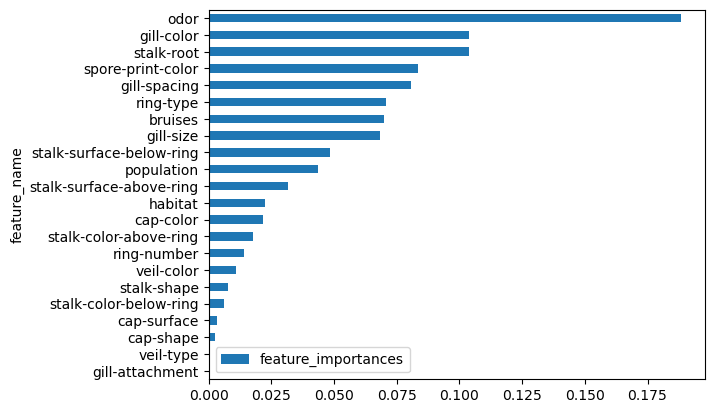

In [288]:
feature_importances_df = pd.DataFrame({'feature_name': best_clf.feature_names_in_,
                                       'feature_importances': best_clf.feature_importances_}).set_index('feature_name')
feature_importances_df.sort_values('feature_importances', ascending=True).plot(kind='barh')

## 3

Теперь у нас есть классификатор, определяющий какие грибы съедобные, а какие нет, испробуем его! Предскажите съедобность этих данных грибов и напишите в ответ число несъедобных грибов (класс равен 1).

In [290]:
testing_mush = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/testing_mush.csv')

In [292]:
testing_mush.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,3,8,1,3,1,0,0,4,0,...,2,7,7,0,2,1,4,2,3,3
1,5,3,4,1,5,1,0,0,10,1,...,2,6,6,0,2,1,4,3,5,0
2,3,3,4,0,8,1,0,1,0,1,...,2,7,6,0,2,1,0,7,4,4
3,3,2,2,0,7,1,0,1,0,1,...,1,6,7,0,2,1,0,7,4,0
4,3,2,2,0,8,1,0,1,0,1,...,1,6,6,0,2,1,0,7,4,4


In [294]:
testing_mush.shape

(2031, 22)

In [302]:
pd.DataFrame(best_clf.predict(testing_mush)).value_counts()

0
0    1055
1     976
Name: count, dtype: int64

## 4

Создайте confusion matrix по предсказаниям, полученным вами в прошлом уроке и правильным ответам

In [354]:
with zipfile.ZipFile('testing_y_mush.zip') as z:
    with z.open('testing_y_mush.csv', pwd='Cool!Move_forward!'.encode('cp850', 'replace')) as f: # specify exact path inside ZIP
        testing_y_mush = pd.read_csv(f)
testing_y_mush.head()

,class
0,0
1,0
2,1
3,1
4,1


In [346]:
# требует пароль
#pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/testing_y_mush.csv.zip', compression='zip')

In [352]:
'Cool!Move_forward!'.encode('cp850', 'replace')

b'Cool!Move_forward!'

In [368]:
y_pred = best_clf.predict(testing_mush)

In [370]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

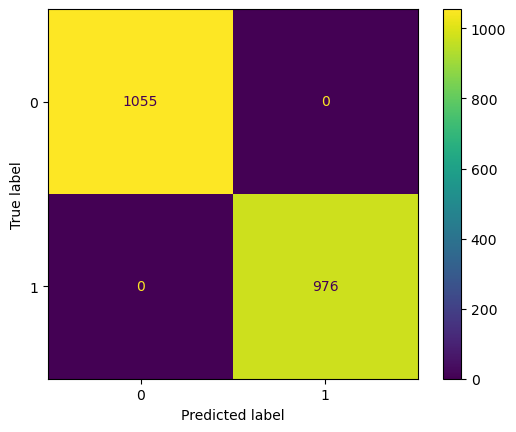

In [376]:
cm = sklearn.metrics.confusion_matrix(y_true = testing_y_mush, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## 5

На Землю нападают войска жукеров, и в их флоте присутствуют транспортники, истребители и крейсеры. Для борьбы с каждым типом кораблей используется свой вид оружия. Как аналитику из Штаба Обороны, вам поручено разработать модель, предсказывающую какие корабли участвуют в атаке, чтобы успешно отбить нападения на различные области планеты

Данных удалось собрать немного, и предсказывать придётся гораздо больший по объёму массив.

Обучите модель и предскажите классы кораблей для новых поступающих данных. Укажите в ответе через пробел число крейсеров, транспортников и истребителей.

In [379]:
invasion = pd.read_csv('invasion.csv')

In [381]:
invasion.head()

,class,g_reflection,i_reflection,speed,brightness,time_of_observance,volume
0,transport,2.190672,6.716633,62.168208,0.347465,158221,44.932446
1,transport,3.453276,8.995909,62.994707,0.590094,385972,41.568300
2,transport,2.432994,6.938691,62.245807,0.329288,446482,40.123467
3,fighter,6.083763,3.019459,18.474555,0.174738,210125,11.384865
4,fighter,12.876769,2.452950,195.805771,0.150446,23109,11.328806


In [384]:
invasion['class'].value_counts()

class
fighter      225
transport    205
cruiser       70
Name: count, dtype: int64

In [388]:
X = invasion.drop('class', axis=1)

In [425]:
y = pd.Series(pd.factorize(invasion['class'])[0])

In [427]:
y

0      0
1      0
2      0
3      1
4      1
      ..
495    1
496    0
497    1
498    1
499    0
Length: 500, dtype: int64

In [429]:
params = ({'n_estimators': range(10, 31, 10),
           'max_depth': range(1, 13, 2),
           'min_samples_leaf': range(1, 8),
           'min_samples_split': range(2, 10, 2)}
         )

In [502]:
clf = RandomForestClassifier(random_state=0)

In [504]:
grid_search_cv_clf = GridSearchCV(estimator=clf, param_grid=params, cv=3)

In [514]:
grid_search_cv_clf

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': range(1, 13, 2),
                         'min_samples_leaf': range(1, 8),
                         'min_samples_split': range(2, 10, 2),
                         'n_estimators': range(10, 31, 10)})

In [506]:
grid_search_cv_clf.fit(X, y)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': range(1, 13, 2),
                         'min_samples_leaf': range(1, 8),
                         'min_samples_split': range(2, 10, 2),
                         'n_estimators': range(10, 31, 10)})

In [508]:
best_clf = grid_search_cv_clf.best_estimator_

In [510]:
grid_search.best_params_

{'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 10}

In [512]:
best_clf.score(X, y)

1.0

In [457]:
X_test = pd.read_csv('operative_information.csv')

In [469]:
predict = pd.DataFrame(best_clf.predict(X_test))

In [494]:
class_transport = {0:  'transport',  1:  'fighter',  2: 'cruiser'}

In [498]:
predict = predict[0].map(class_transport)

In [500]:
predict.value_counts()

0
fighter      675
transport    595
cruiser      230
Name: count, dtype: int64

## 6

Какая переменная оказалась самой важной для классифицирования кораблей?

<Axes: ylabel='feature_name'>

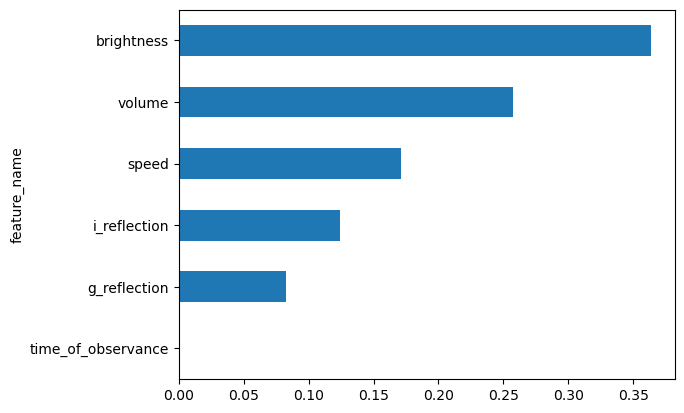

In [524]:
feature_importances_df = pd.DataFrame({'feature_name': best_clf.feature_names_in_,
                                       'feature_importances': best_clf.feature_importances_}).set_index('feature_name')
feature_importances_df.sort_values('feature_importances', ascending=True).plot(kind='barh', legend=False)

In [528]:
best_clf.feature_names_in_

array(['g_reflection', 'i_reflection', 'speed', 'brightness',
       'time_of_observance', 'volume'], dtype=object)

## 7 

Проанализируйте имеющиеся данные об опасности разных регионов космоса и укажите наиболее вероятные причины угрозы

In [534]:
space = pd.read_csv('space_can_be_a_dangerous_place.csv')

In [536]:
space.head()

,r,phi,peradventure_index,dustiness,black_hole_is_near,buggers_were_noticed,nearby_system_has_planemo,dangerous
0,169.1,138.0,22.3212,0.706285,0,1,1,1
1,11.1,148.0,1.4652,-0.410512,1,1,1,1
2,274.6,201.0,36.2472,0.756457,1,1,1,1
3,172.8,173.0,22.8096,0.035221,1,1,1,1
4,223.3,222.0,29.4756,0.197271,0,1,1,1


Близость к чёрной дыре сильно связана с опасностью - может быть инопланетяне как-то используют их (или находиться рядом с чёрной дырой не лучшая идея)

In [571]:
space.groupby('black_hole_is_near').agg({'dangerous': ['count', 'mean']})

dangerous          
                       count      mean
black_hole_is_near                    
0                      89001  0.896484
1                      10999  0.946813

Не можем сказать, мало каунтов по черной дыре

In [573]:
from scipy import stats

In [576]:
contingency_table = pd.crosstab(space['black_hole_is_near'], space['dangerous'], margins=True)
contingency_table

dangerous,0,1,All
black_hole_is_near,,,
0,9213,79788,89001
1,585,10414,10999
All,9798,90202,100000


In [578]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

In [583]:
p_value

1.684291890429916e-59

Связь есть. Чтобы сказать сильная она или нет, можно исопльзовать тест Крамера (?). Судя по ответу не сильная.

Наличие планемо увеличивает опасность - возможно жукеры строят свои базы на этих телах

In [553]:
space.groupby('nearby_system_has_planemo').agg({'buggers_were_noticed': ['count', 'mean']})

buggers_were_noticed          
                                         count      mean
nearby_system_has_planemo                               
0                                          965  0.937824
1                                        99035  0.929914

То же самое

In [586]:
contingency_table = pd.crosstab(space['nearby_system_has_planemo'], space['dangerous'], margins=True)
contingency_table

dangerous,0,1,All
nearby_system_has_planemo,,,
0,965,0,965
1,8833,90202,99035
All,9798,90202,100000


In [588]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

In [590]:
p_value

0.0

Да. Есть связь

Присутствие жукеров в системе - очевидный сигнал об опасности

In [561]:
space.groupby('buggers_were_noticed').agg({'dangerous': ['count', 'mean']})

dangerous          
                         count      mean
buggers_were_noticed                    
0                         7001  0.528782
1                        92999  0.930118

In [592]:
contingency_table = pd.crosstab(space['buggers_were_noticed'], space['dangerous'], margins=True)
contingency_table

dangerous,0,1,All
buggers_were_noticed,,,
0,3299,3702,7001
1,6499,86500,92999
All,9798,90202,100000


In [594]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

In [596]:
p_value

0.0

Вывод:

- Наличие планемо увеличивает опасность - возможно жукеры строят свои базы на этих телах
- Присутствие жукеров в системе - очевидный сигнал об опасности